# Ejercicio 6 - Validacion espacial y temporal

Parte 2 del Laboratorio 4 (Machine Learning). Reentrena los tres modelos
que ya eligio el ejercicio anterior (`src/modelos.py`, `src/evaluacion.py`),
con exactamente los mismos hiperparametros, bajo dos esquemas de
evaluacion distintos de la particion aleatoria 70/30: agrupando por
bloque espacial y encadenando por fecha. El objetivo no es buscar un
modelo mejor, es medir cuanto cambia el desempeno ya medido cuando el
conjunto de prueba deja de tener observaciones casi identicas a las de
entrenamiento.

Depende de los modelos ya entrenados y evaluados
(`notebooks/12_modelos.ipynb`, `notebooks/13_evaluacion.ipynb`). No
ajusta hiperparametros nuevos.


## 0. Verificacion del trabajo previo (gate)

Antes de reentrenar nada se exige que la particion, los modelos y la
evaluacion del ejercicio anterior pasen su propio contrato. Si esto
falla, el problema esta ahi, no aqui.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from src.modelos import verificar_modelos
from src.evaluacion import leer_metricas, verificar_evaluacion

resumen_modelos = verificar_modelos()
print(f"Gate de modelos correcto: {resumen_modelos['entrenamiento']} observaciones de entrenamiento, "
      f"{resumen_modelos['prueba']} de prueba, {resumen_modelos['positivos_prueba']} positivas en prueba.")

resumen_evaluacion = verificar_evaluacion()
print(f"Gate de evaluacion correcto: mejor modelo segun F2 es {resumen_evaluacion['mejor']}.")

metricas_baseline = {fila['modelo']: fila for fila in leer_metricas()}


Gate de modelos correcto: 344864 observaciones de entrenamiento, 147799 de prueba, 1910 positivas en prueba.
Gate de evaluacion correcto: mejor modelo segun F2 es gradient_boosting.


## 1. Cuadricula de bloques espaciales

Antes de fijar un tamano de bloque hay que comprobar que alcanza:
cuantos bloques da, y cuantos de esos bloques contienen al menos un
positivo. Con muy pocos bloques, la validacion cruzada agrupada tiene
poco margen para repartir el desbalance entre pliegues.


In [2]:
from src.validacion import evaluar_tamanos_bloque, tabla_bloques

tabla_bloq = tabla_bloques()
print(f"Observaciones con bloque asignado: {len(tabla_bloq)}")

print()
print("Amatitlan: 1 km del enunciado, comparado contra 500 m")
for fila in evaluar_tamanos_bloque(tabla_bloq, "amatitlan", tamanos=(1000.0, 500.0)):
    print(f"  {fila['tamano_bloque_m']:.0f} m: {fila['n_bloques']} bloques, "
          f"{fila['n_bloques_con_positivo']} con algun positivo, "
          f"{fila['obs_por_bloque_mediana']:.1f} obs/bloque en la mediana")

print()
print("Atitlan: 1 km (no se refina, ver justificacion abajo)")
for fila in evaluar_tamanos_bloque(tabla_bloq, "atitlan", tamanos=(1000.0,)):
    print(f"  {fila['tamano_bloque_m']:.0f} m: {fila['n_bloques']} bloques, "
          f"{fila['n_bloques_con_positivo']} con algun positivo, "
          f"{fila['obs_por_bloque_mediana']:.1f} obs/bloque en la mediana")


Observaciones con bloque asignado: 492663

Amatitlan: 1 km del enunciado, comparado contra 500 m
  1000 m: 35 bloques, 34 con algun positivo, 1123.0 obs/bloque en la mediana
  500 m: 95 bloques, 90 con algun positivo, 685.0 obs/bloque en la mediana

Atitlan: 1 km (no se refina, ver justificacion abajo)


  1000 m: 168 bloques, 3 con algun positivo, 3378.0 obs/bloque en la mediana


**Decision:** Amatitlan se deja en 500 m. A 1 km el numero de bloques
queda estrecho para repartir en varios pliegues de validacion cruzada
agrupada; a 500 m el numero de bloques crece bastante y casi todos siguen
teniendo algun positivo, asi que no se pierde cobertura por refinar la
cuadricula. Atitlan se deja en 1 km: su problema no es de resolucion,
es que solo un punado de sus bloques concentra los 7 positivos que tiene
en total. Refinar la cuadricula ahi no agrega positivos donde no los hay,
solo fragmenta mas un problema de escasez absoluta. Esta decision queda
fija en `validacion.TAMANO_BLOQUE_M`.


In [3]:
from src.validacion import TAMANO_BLOQUE_M, escribir_bloques, resumen_bloques

tabla_bloq = tabla_bloques(tamano_por_lago=TAMANO_BLOQUE_M)
filas_bloques = resumen_bloques(tabla_bloq, tamano_por_lago=TAMANO_BLOQUE_M)
escribir_bloques(filas_bloques)
display(pd.DataFrame(filas_bloques))


,lago,tamano_bloque_m,n_bloques,n_bloques_con_positivo,obs_por_bloque_min,obs_por_bloque_mediana,obs_por_bloque_max
0,amatitlan,500.0,95,90,10,685.0,1100
1,atitlan,1000.0,168,3,3,3378.0,3970


## 2. Mapa de bloques

Cada observacion queda asignada a exactamente un bloque. El mapa muestra
la cuadricula sobre el contorno real de cada lago, coloreando cada
observacion segun si su bloque contiene o no algun caso de alta
presencia.


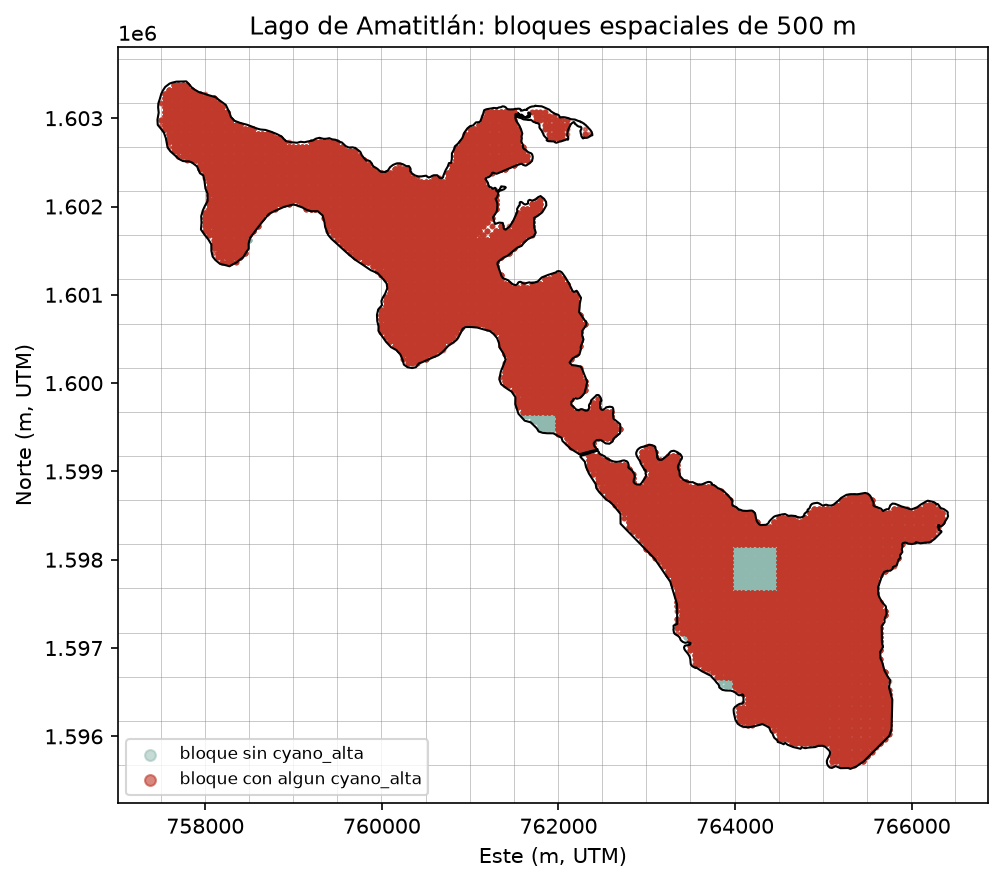

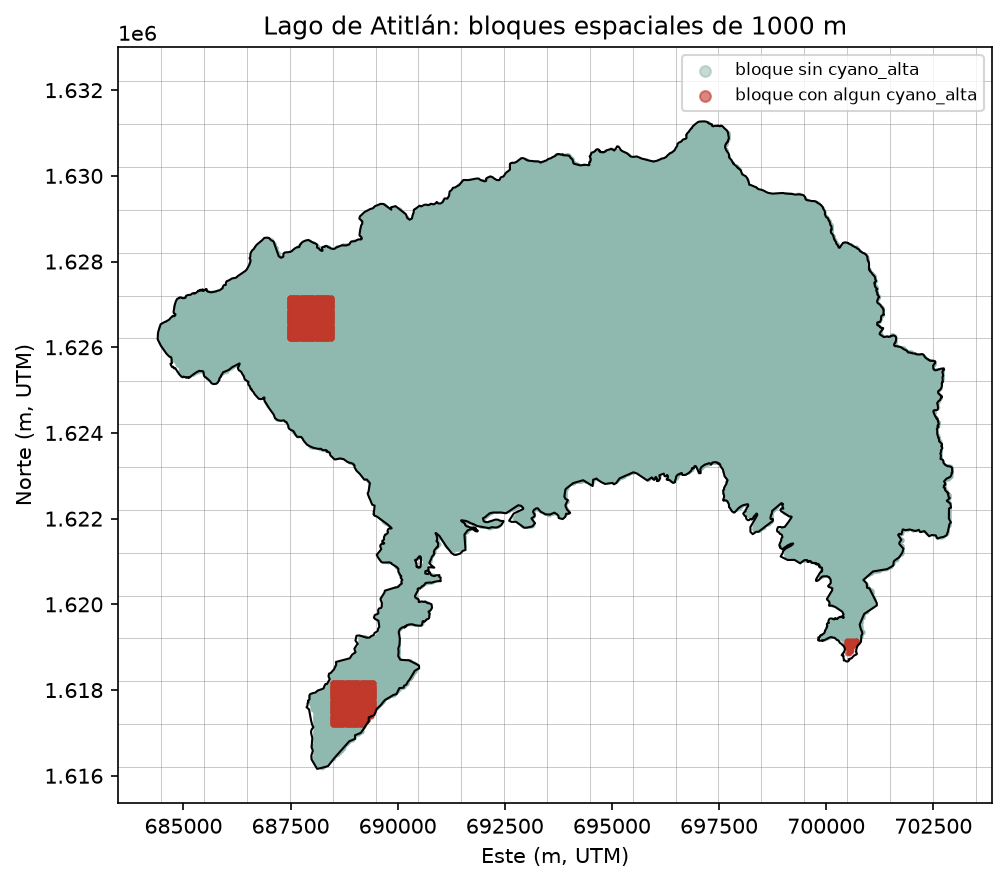

In [4]:
from src.validacion import figura_bloques

for lago in ("amatitlan", "atitlan"):
    ruta = figura_bloques(tabla_bloq, lago, tamano_por_lago=TAMANO_BLOQUE_M)
    display(Image(filename=str(ruta)))


**Lectura:** en Amatitlan casi todo el lago queda en rojo, la alta
presencia esta repartida por buena parte del espejo de agua. En Atitlan
solo unas pocas manchas puntuales concentran toda la senal positiva del
lago, consistente con que solo 7 celdas de 432,035 superan el umbral en
todo el periodo.


## 3. Validacion cruzada agrupada por bloque

`GroupKFold` garantiza, por construccion, que ningun bloque cae a la vez
en entrenamiento y en prueba del mismo pliegue. Se verifica igual de
forma explicita antes de reentrenar nada, en vez de asumir que el uso de
`GroupKFold` esta bien hecho.


In [5]:
from src.validacion import verificar_grupos_no_se_reparten

verificar_grupos_no_se_reparten()
print("Ningun bloque se reparte entre entrenamiento y prueba del mismo pliegue.")


Ningun bloque se reparte entre entrenamiento y prueba del mismo pliegue.


## 4. Reentrenamiento bajo validacion espacial

Los tres modelos se reentrenan con exactamente los mismos
hiperparametros que ya eligio `modelos.py` (se clona el estimador
persistido), sobre cada uno de los cinco pliegues de `GroupKFold`.


In [6]:
from src.validacion import escribir_metricas_espacial, promedio_por_modelo, validar_espacial

filas_espacial = validar_espacial()
escribir_metricas_espacial(filas_espacial)
display(pd.DataFrame(filas_espacial)[
    ["modelo", "pliegue", "n_prueba", "positivos_prueba", "n_bloques_prueba", "precision", "recall", "f2"]
])


,modelo,pliegue,n_prueba,positivos_prueba,n_bloques_prueba,precision,recall,f2
0,regresion_logistica,0,98534,1018,52,0.267957,0.993124,0.644359
1,regresion_logistica,1,98531,1104,53,0.284047,0.991848,0.661951
2,regresion_logistica,2,98535,1688,52,0.448793,0.957938,0.780782
3,regresion_logistica,3,98532,1368,52,0.364861,0.989766,0.737232
4,regresion_logistica,4,98531,1187,54,0.257267,0.999158,0.633682
5,random_forest,0,98534,1018,52,0.812974,0.947937,0.917475
6,random_forest,1,98531,1104,53,0.830769,0.929348,0.907804
7,random_forest,2,98535,1688,52,0.906690,0.915284,0.913553
8,random_forest,3,98532,1368,52,0.827284,0.966374,0.934936
9,random_forest,4,98531,1187,54,0.788701,0.905644,0.879561


In [7]:
promedio_espacial = promedio_por_modelo(filas_espacial)
filas_comparacion = []
for modelo, resumen in promedio_espacial.items():
    filas_comparacion.append({
        "modelo": modelo,
        "f2_aleatorio_70_30": float(metricas_baseline[modelo]["f2"]),
        "f2_espacial_promedio": resumen["f2"],
        "diferencia": round(resumen["f2"] - float(metricas_baseline[modelo]["f2"]), 4) if resumen["f2"] != "indefinido" else "indefinido",
    })
display(pd.DataFrame(filas_comparacion))


,modelo,f2_aleatorio_70_30,f2_espacial_promedio,diferencia
0,regresion_logistica,0.691521,0.691601,0.0001
1,random_forest,0.941242,0.910666,-0.0306
2,gradient_boosting,0.957665,0.922529,-0.0351


## 5-6. Comparacion contra la particion aleatoria

**Lectura:** el desempeno baja en los dos modelos de arboles (unos 3 a 4
puntos de F2) y se mantiene practicamente igual en la Regresion
Logistica. La caida es real pero moderada. La explicacion es la que
anticipa el enunciado: en la particion aleatoria, dos celdas de 50 m
contiguas de la misma fecha son casi el mismo pixel, asi que el conjunto
de prueba aleatorio casi siempre tiene una vecina casi identica en el de
entrenamiento. Agrupar por bloque elimina esa fuga de informacion entre
vecinos, y la estimacion que queda es mas honesta, aunque mas baja. La
Regresion Logistica, con menos capacidad de memorizar patrones locales
finos que un arbol, es la que menos se ve afectada por esa fuga en primer
lugar, asi que su desempeno casi no cambia.


## Validacion temporal

No la describe la seccion de ejercicios, pero la rubrica la puntua de
forma explicita dentro de "validacion geoespacial y temporal". Se
implementan dos estrategias, agrupando por fecha en vez de por
observacion individual:

- **Encadenamiento hacia adelante**: entrena con todas las fechas
  anteriores a una fecha de prueba, evalua sobre esa fecha, avanzando
  fecha por fecha.
- **Dejar una fecha fuera**: entrena con las demas fechas, evalua sobre
  la que queda fuera, una vez por cada fecha distinta del dataset.

Con el desbalance extremo de este dataset, muchos pliegues quedan sin
ningun positivo de prueba, o incluso sin ningun positivo de
entrenamiento en las primeras fechas del encadenamiento. Esos casos se
marcan explicitamente como "indefinido" en vez de forzarlos a cero.


In [8]:
from src.validacion import escribir_metricas_temporal, validar_temporal

filas_temporal = validar_temporal()
escribir_metricas_temporal(filas_temporal)

indefinidos = sum(1 for f in filas_temporal if f["f2"] == "indefinido")
sin_entrenar = sum(1 for f in filas_temporal if f["accuracy"] == "indefinido")
print(f"{len(filas_temporal)} pliegues temporales en total.")
print(f"{indefinidos} con F2 indefinido (sin positivos de prueba o de entrenamiento).")
print(f"De esos, {sin_entrenar} no se pudieron ni entrenar (sin positivos todavia en el historial).")


117 pliegues temporales en total.
54 con F2 indefinido (sin positivos de prueba o de entrenamiento).
De esos, 9 no se pudieron ni entrenar (sin positivos todavia en el historial).


In [9]:
tabla_temporal = pd.DataFrame(filas_temporal)
display(
    tabla_temporal[tabla_temporal["estrategia"] == "encadenado"][
        ["modelo", "fecha_prueba", "n_fechas_entrenamiento", "positivos_prueba", "recall", "f2"]
    ].reset_index(drop=True)
)


,modelo,fecha_prueba,n_fechas_entrenamiento,positivos_prueba,recall,f2
0,regresion_logistica,2025-01-28,1,0,indefinido,indefinido
1,regresion_logistica,2025-04-13,2,0,indefinido,indefinido
2,regresion_logistica,2025-04-15,3,23,indefinido,indefinido
3,regresion_logistica,2025-04-28,4,390,0.928205,0.640708
4,regresion_logistica,2025-05-13,5,0,indefinido,indefinido
5,regresion_logistica,2025-07-17,6,2,0.0,0.0
6,regresion_logistica,2025-11-21,7,3,1.0,0.002287
7,regresion_logistica,2025-11-24,8,87,1.0,0.078308
8,regresion_logistica,2025-12-29,9,2,1.0,0.454545
9,regresion_logistica,2026-01-08,10,347,0.62536,0.661989


In [10]:
filas_comparacion_temporal = []
for estrategia in ("encadenado", "leave_one_date_out"):
    subconjunto = [f for f in filas_temporal if f["estrategia"] == estrategia]
    promedio = promedio_por_modelo(subconjunto)
    for modelo, resumen in promedio.items():
        filas_comparacion_temporal.append({
            "modelo": modelo,
            "estrategia": estrategia,
            "f2_promedio": resumen["f2"],
            "pliegues_definidos": resumen["f2_pliegues_definidos"],
            "pliegues_totales": resumen["n_pliegues"],
        })
display(pd.DataFrame(filas_comparacion_temporal))


,modelo,estrategia,f2_promedio,pliegues_definidos,pliegues_totales
0,regresion_logistica,encadenado,0.384427,10,19
1,random_forest,encadenado,0.245923,10,19
2,gradient_boosting,encadenado,0.324662,10,19
3,regresion_logistica,leave_one_date_out,0.255339,11,20
4,random_forest,leave_one_date_out,0.261379,11,20
5,gradient_boosting,leave_one_date_out,0.344269,11,20


**Lectura:** la caida es mucho mas severa que en la validacion espacial.
El F2 del Gradient Boosting, el mejor modelo bajo el esquema aleatorio,
cae a menos de la mitad bajo cualquiera de las dos estrategias
temporales; el Random Forest, segundo mejor bajo el esquema aleatorio, es
el que mas sufre bajo encadenamiento. La razon esta en como se
distribuyen los positivos en el tiempo: mas del 90 por ciento de los
casos de alta presencia de Amatitlan se concentran en solo dos fechas.
Un modelo que nunca vio esas fechas en su historial de entrenamiento no
tiene de donde aprender el patron que las distingue, y un modelo
evaluado sobre una fecha distinta a esas dos tiene poco que predecir de
todas formas. La validacion temporal expone algo que la espacial no: el
problema no es solo de vecindad geografica, es que la senal de alta
presencia esta concentrada en muy pocos momentos del calendario.


## Conclusion de esta seccion

Las dos validaciones coinciden en que la particion aleatoria 70/30 es
optimista, pero no en la misma magnitud. La espacial rebaja el F2 del
mejor modelo unos pocos puntos porcentuales: un ajuste moderado. La
temporal lo rebaja a menos de la mitad: la capacidad de generalizar a un
momento del calendario distinto es, con los datos de este laboratorio,
bastante mas limitada que la de generalizar a un lugar geografico
distinto dentro del mismo periodo. Cualquier afirmacion sobre que tan
bien funcionaria este modelo en produccion debe apoyarse en estas cifras,
no en las del 70/30 aleatorio, que sobrestiman el desempeno real.


## Verificacion final (gate para el ejercicio 7)


In [11]:
from src.validacion import verificar_validacion

resumen_gate = verificar_validacion()
print(f"Verificacion correcta: {resumen_gate['bloques']['bloques_totales']} bloques en total.")
for ruta in resumen_gate["tablas"]:
    print(f"  {ruta}")


Verificacion correcta: 263 bloques en total.
  D:\Tareas\Data Science\Laboratorio 4 Parte 2\results\tables\bloques_espaciales.csv
  D:\Tareas\Data Science\Laboratorio 4 Parte 2\results\tables\metricas_validacion_espacial.csv
  D:\Tareas\Data Science\Laboratorio 4 Parte 2\results\tables\metricas_validacion_temporal.csv
  D:\Tareas\Data Science\Laboratorio 4 Parte 2\results\tables\metricas_generalizacion_lagos.csv
